# NLP Lab Assignment 5 — N-gram Language Models with Add-K Smoothing

**AI357 — Natural Language Processing**

Builds on Assignment 4 and applies **Add-K smoothing** (where $K=0.3$) to all 4 models developed in the previous assignment:
- **Unigram, Bigram, Trigram, Quadrigram**

Formula for Add-K smoothing:
$$P_{add-k}(w_i \mid w_{i-N+1}^{i-1}) = \frac{C(w_{i-N+1}^{i-1}, w_i) + k}{C(w_{i-N+1}^{i-1}) + k \cdot V}$$

We will test it on the test and validation/development sets, showing perplexity values, comparison tables, and generated texts.

## 0. Setup

In [4]:
%pip install -q datasets pandas pyarrow tqdm matplotlib


Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import re
import math
import random
import json
from collections import defaultdict, Counter

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

random.seed(42)

os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

TOKENIZED_PATH = "data/hindi_tokenized_corpus.csv"
RESULTS_PATH = "results/assignment5_results.json"

DEV_SIZE = 1000
TEST_SIZE = 1000

results = {}

print("Tokenized corpus cache :", os.path.abspath(TOKENIZED_PATH))
print("Consolidated results   :", os.path.abspath(RESULTS_PATH))


Tokenized corpus cache : /Users/ritweekraj/Desktop/NLP/Assignment_5/data/hindi_tokenized_corpus.csv
Consolidated results   : /Users/ritweekraj/Desktop/NLP/Assignment_5/results/assignment5_results.json


/Users/ritweekraj/Desktop/NLP/Assignment_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tokenizer (from Assignment 1)

In [6]:
URL_RE = r'(?:https?://|www\\.)[^\\s]+'
EMAIL_RE = r'[\\w.\\-]+@[\\w.\\-]+\\.\\w+'
DATE_RE = r'\\d{1,2}[/-]\\d{1,2}[/-]\\d{2,4}'
NUM_RE = r'\\d+(?:\\.\\d+)?'
WORD_RE = r"[\\u0900-\\u0963\\u0966-\\u097F]+|[A-Za-z]+"   # Devanagari, excluding danda/double-danda
PUNCT_RE = r'[।॥,;:!?"\'()\\{\\}\\[\\]—–\\-…]'

TOKEN_PATTERN = re.compile(f'({URL_RE})|({EMAIL_RE})|({DATE_RE})|({NUM_RE})|({WORD_RE})|({PUNCT_RE})')
SENT_SPLIT_RE = re.compile(r'(?<=[।॥!?.])\\s+')


def sentence_tokenize(paragraph: str):
    paragraph = paragraph.strip()
    if not paragraph:
        return []
    return [s.strip() for s in SENT_SPLIT_RE.split(paragraph) if s.strip()]


def word_tokenize(sentence: str):
    return [m.group(0) for m in TOKEN_PATTERN.finditer(sentence)]


## 2. Load Hindi Corpus

In [7]:
def load_tokenized_corpus(path=TOKENIZED_PATH):
    if os.path.exists(path):
        print(f"Loading corpus from {os.path.abspath(path)}")
        return pd.read_csv(path)
    else:
        raise FileNotFoundError(f"Corpus file not found at {path}. Please copy it from Assignment_4.")

corpus_df = load_tokenized_corpus()
print("Corpus shape:", corpus_df.shape)
corpus_df.head(10)


Loading corpus from /Users/ritweekraj/Desktop/NLP/Assignment_5/data/hindi_tokenized_corpus.csv
Corpus shape: (100000, 1)


,tokenized_sentence
0,लोगों को बिलों संबंधी सुविधा देना ही उनका काम
1,इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थ...
2,हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के ...
3,1989 में देवीलाल केन्द्र की राजनीति में सक्रिय...
4,उन परिस्थितियों में देवीलाल ने कड़ा निर्णय लेत...
5,उस समय रणजीत की नाराजगी के चलते उनके समर्थन मे...
6,देवीलाल की हरियाणा की जनता पर इतनी मजबूत पकड़ ...
7,ओमप्रकाश चौटाला पिछले काफी समय से जेल में हैं ...
8,जहां आई थी तबाही उस घाटी क्षेत्र में खतरा ज्यादा
9,इसके बाद केंद्र की ओर से प्रदेश सरकार को पीएमज...


## 3. Corpus Statistics

In [8]:
all_sentences = [str(s).split(" ") for s in corpus_df["tokenized_sentence"].tolist()]

total_sentences = len(all_sentences)
total_words = sum(len(s) for s in all_sentences)
total_chars = sum(sum(len(w) for w in s) for s in all_sentences)
avg_sent_len = total_words / total_sentences
avg_word_len = total_chars / total_words
flat_tokens = [w for s in all_sentences for w in s]
ttr = len(set(flat_tokens)) / len(flat_tokens)

corpus_stats = {
    "total_sentences": total_sentences,
    "total_words": total_words,
    "total_characters": total_chars,
    "avg_sentence_length": avg_sent_len,
    "avg_word_length": avg_word_len,
    "type_token_ratio": ttr,
}
results["corpus_stats"] = corpus_stats

pd.DataFrame([corpus_stats]).T.rename(columns={0: "value"})


,value
total_sentences,1.000000e+05
total_words,1.937298e+06
total_characters,7.272089e+06
avg_sentence_length,1.937298e+01
avg_word_length,3.753728e+00
type_token_ratio,3.879269e-02


## 4. Train / Dev / Test Split

In [9]:
random.seed(42)
random.shuffle(all_sentences)

dev_sentences = all_sentences[:DEV_SIZE]
test_sentences = all_sentences[DEV_SIZE:DEV_SIZE + TEST_SIZE]
train_sentences = all_sentences[DEV_SIZE + TEST_SIZE:]

results["split_sizes"] = {
    "train": len(train_sentences),
    "dev": len(dev_sentences),
    "test": len(test_sentences),
}
print(results["split_sizes"])


{'train': 98000, 'dev': 1000, 'test': 1000}


## 5. Building the N-gram models

In [10]:
def pad_sentence(tokens, n):
    return ["<s>"] * (n - 1) + tokens + ["</s>"]


def build_ngram_counts(sentences, n):
    ngram_counts = defaultdict(int)
    context_counts = defaultdict(int)
    for tokens in tqdm(sentences, desc=f"Building {n}-gram counts", leave=False):
        padded = pad_sentence(tokens, n)
        for i in range(len(padded) - n + 1):
            ngram = tuple(padded[i:i + n])
            ngram_counts[ngram] += 1
            context_counts[ngram[:-1]] += 1
    return ngram_counts, context_counts


vocab = set()
for tokens in train_sentences:
    vocab.update(tokens)
vocab.update(["<s>", "</s>"])
V = len(vocab)
print(f"Vocabulary size (V): {V:,}")

results["vocab_size"] = V
results["vocab"] = vocab


Vocabulary size (V): 74,330


In [11]:
models = {}
model_summary_rows = []
top_ngrams = {}

for n, name in [(1, "unigram"), (2, "bigram"), (3, "trigram"), (4, "quadrigram")]:
    ngram_counts, context_counts = build_ngram_counts(train_sentences, n)
    models[name] = {"n": n, "ngram_counts": ngram_counts, "context_counts": context_counts}

    top10 = Counter(ngram_counts).most_common(10)
    top_ngrams[name] = [(" ".join(g), c) for g, c in top10]

    unique_ngrams = len(ngram_counts)
    total_occ = sum(ngram_counts.values())
    model_summary_rows.append({"model": name, "n": n, "unique_ngrams": unique_ngrams, "total_occurrences": total_occ})
    print(f"{name:12s} -> {unique_ngrams:,} unique n-grams | top 3: {top_ngrams[name][:3]}")

model_summary_df = pd.DataFrame(model_summary_rows)
results["model_summary"] = model_summary_df
results["top_ngrams"] = top_ngrams
results["models"] = models

model_summary_df


unigram      -> 74,329 unique n-grams | top 3: [('</s>', 98000), ('के', 72421), ('।', 71428)]


bigram       -> 629,310 unique n-grams | top 3: [('। </s>', 70068), ('है ।', 23281), ('के लिए', 10232)]


trigram      -> 1,298,378 unique n-grams | top 3: [('है । </s>', 22852), ('हैं । </s>', 8518), ('<s> <s> इस', 3939)]


quadrigram   -> 1,627,469 unique n-grams | top 3: [('<s> <s> <s> इस', 3939), ('<s> <s> <s> उन्होंने', 2250), ('<s> <s> <s> इसके', 2199)]


,model,n,unique_ngrams,total_occurrences
0,unigram,1,74329,1997282
1,bigram,2,629310,1997282
2,trigram,3,1298378,1997282
3,quadrigram,4,1627469,1997282


In [12]:
for name, rows in top_ngrams.items():
    print(f"\nTop 10 {name}s:")
    for gram, count in rows:
        print(f"  {gram:30s} {count}")



Top 10 unigrams:
  </s>                           98000
  के                             72421
  ।                              71428
  में                            55504
  है                             45840
  की                             44760
  ,                              39708
  को                             33950
  से                             32027
  ने                             25058

Top 10 bigrams:
  । </s>                         70068
  है ।                           23281
  के लिए                         10232
  हैं ।                          8681
  है </s>                        5473
  है कि                          5128
  के साथ                         4275
  <s> इस                         3939
  है ,                           3825
  कहा कि                         3809

Top 10 trigrams:
  है । </s>                      22852
  हैं । </s>                     8518
  <s> <s> इस                     3939
  था । </s>                      3217
  <s> <s> उन्होंने   

## 6. Add-K Smoothing ($K=0.3$)

Formula:
$$P_{add-k}(w_i \mid w_{i-N+1}^{i-1}) = \dfrac{C(w_{i-N+1}^{i-1}, w_i) + K}{C(w_{i-N+1}^{i-1}) + K \cdot V}$$

In [13]:
total_unigram_tokens = sum(models["unigram"]["ngram_counts"].values())
K_smooth = 0.3

def add_k_probability(ngram, model, V, k=K_smooth):
    n = model["n"]
    count_ngram = model["ngram_counts"].get(ngram, 0)
    count_context = total_unigram_tokens if n == 1 else model["context_counts"].get(ngram[:-1], 0)
    return (count_ngram + k) / (count_context + k * V)


example_sentence = train_sentences[0]
print("Example sentence:", example_sentence)
for name, model in models.items():
    n = model["n"]
    ngram = tuple(pad_sentence(example_sentence, n)[:n])
    print(f"{name:12s} P({ngram}) = {add_k_probability(ngram, model, V):.3e}")


Example sentence: ['आज', 'आपका', 'दिन', 'उतार', 'चढ़ाव', 'भरा', 'रहेगा', '।']
unigram      P(('आज',)) = 8.290e-04
bigram       P(('<s>', 'आज')) = 3.153e-03
trigram      P(('<s>', '<s>', 'आज')) = 3.153e-03
quadrigram   P(('<s>', '<s>', '<s>', 'आज')) = 3.153e-03


## 7. Perplexity evaluation (dev & test)

In [14]:
def sentence_log_prob(tokens, model, V, k=K_smooth):
    n = model["n"]
    padded = pad_sentence(tokens, n)
    log_prob, count = 0.0, 0
    for i in range(len(padded) - n + 1):
        ngram = tuple(padded[i:i + n])
        log_prob += math.log(add_k_probability(ngram, model, V, k))
        count += 1
    return log_prob, count


def sentence_perplexities(sentences, model, V, k=K_smooth):
    ppls = []
    for tokens in sentences:
        log_prob, count = sentence_log_prob(tokens, model, V, k)
        ppls.append(math.exp(-log_prob / count))
    return ppls


perplexity_summary_rows = []
per_sentence_perplexities = {}

for name, model in models.items():
    n = model["n"]

    # aggregate (proper) perplexity
    def aggregate_ppl(sentences):
        total_log_prob, total_tokens = 0.0, 0
        for tokens in sentences:
            lp, c = sentence_log_prob(tokens, model, V, K_smooth)
            total_log_prob += lp
            total_tokens += c
        return math.exp(-total_log_prob / total_tokens)

    dev_agg = aggregate_ppl(dev_sentences)
    test_agg = aggregate_ppl(test_sentences)

    dev_ppls = sentence_perplexities(dev_sentences, model, V, K_smooth)
    test_ppls = sentence_perplexities(test_sentences, model, V, K_smooth)
    per_sentence_perplexities[name] = {"dev": dev_ppls, "test": test_ppls}

    perplexity_summary_rows.append({
        "model": name,
        "dev_perplexity_aggregate": dev_agg,
        "test_perplexity_aggregate": test_agg,
        "dev_perplexity_mean": sum(dev_ppls) / len(dev_ppls),
        "dev_perplexity_min": min(dev_ppls),
        "dev_perplexity_max": max(dev_ppls),
        "test_perplexity_mean": sum(test_ppls) / len(test_ppls),
        "test_perplexity_min": min(test_ppls),
        "test_perplexity_max": max(test_ppls),
    })
    print(f"{name:12s} | Dev PPL: {dev_agg:10.3f} | Test PPL: {test_agg:10.3f}")

perplexity_summary_df = pd.DataFrame(perplexity_summary_rows)
results["perplexity_summary"] = perplexity_summary_df
results["per_sentence_perplexities"] = per_sentence_perplexities

perplexity_summary_df


unigram      | Dev PPL:   1429.042 | Test PPL:   1410.663
bigram       | Dev PPL:   2146.647 | Test PPL:   2103.348
trigram      | Dev PPL:  14951.959 | Test PPL:  14426.854
quadrigram   | Dev PPL:  35057.079 | Test PPL:  33668.235


,model,dev_perplexity_aggregate,test_perplexity_aggregate,dev_perplexity_mean,dev_perplexity_min,dev_perplexity_max,test_perplexity_mean,test_perplexity_min,test_perplexity_max
0,unigram,1429.041542,1410.662666,1733.368382,127.161055,39434.840571,1958.226179,29.499380,97747.270291
1,bigram,2146.647054,2103.348048,3383.969730,68.634479,130420.087735,3590.144560,33.703710,130363.599302
2,trigram,14951.959173,14426.853591,18990.989387,540.476730,130367.496628,18952.570627,103.702878,130363.599302
3,quadrigram,35057.079394,33668.234889,37722.691818,577.109207,130363.599302,36701.926572,110.560771,130363.599302


## 8. Final comparison table & chart

In [15]:
final_comparison_df = model_summary_df.merge(
    perplexity_summary_df[["model", "dev_perplexity_aggregate", "test_perplexity_aggregate"]],
    on="model",
)
final_comparison_df["vocab_size"] = V
final_comparison_df["train_sentences"] = len(train_sentences)
final_comparison_df["dev_sentences"] = len(dev_sentences)
final_comparison_df["test_sentences"] = len(test_sentences)

results["final_comparison"] = final_comparison_df
final_comparison_df


,model,n,unique_ngrams,total_occurrences,dev_perplexity_aggregate,test_perplexity_aggregate,vocab_size,train_sentences,dev_sentences,test_sentences
0,unigram,1,74329,1997282,1429.041542,1410.662666,74330,98000,1000,1000
1,bigram,2,629310,1997282,2146.647054,2103.348048,74330,98000,1000,1000
2,trigram,3,1298378,1997282,14951.959173,14426.853591,74330,98000,1000,1000
3,quadrigram,4,1627469,1997282,35057.079394,33668.234889,74330,98000,1000,1000


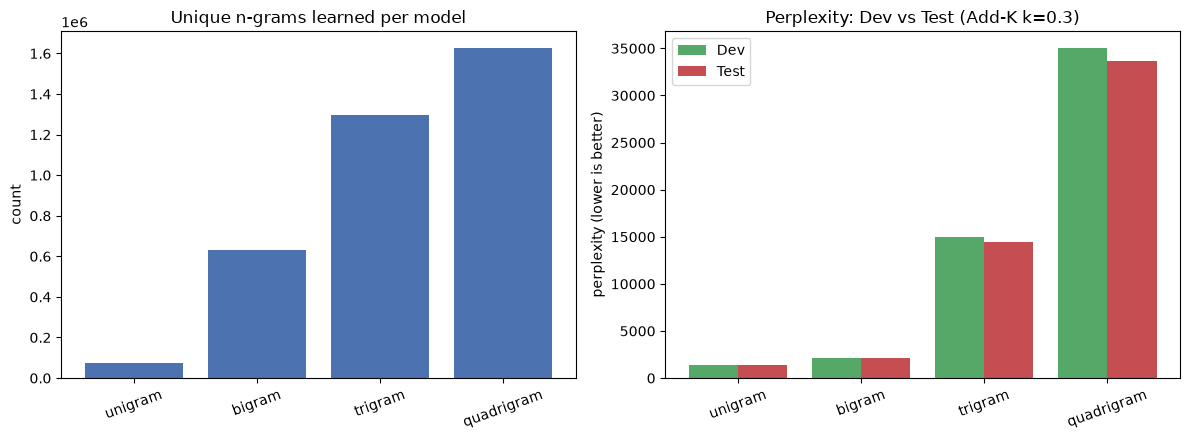

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ["unigram", "bigram", "trigram", "quadrigram"]
plot_df = final_comparison_df.set_index("model").loc[order]

axes[0].bar(order, plot_df["unique_ngrams"], color="#4C72B0")
axes[0].set_title("Unique n-grams learned per model")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

x = range(len(order))
axes[1].bar([i - 0.2 for i in x], plot_df["dev_perplexity_aggregate"], width=0.4, label="Dev", color="#55A868")
axes[1].bar([i + 0.2 for i in x], plot_df["test_perplexity_aggregate"], width=0.4, label="Test", color="#C44E52")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(order, rotation=20)
axes[1].set_title("Perplexity: Dev vs Test (Add-K k=0.3)")
axes[1].set_ylabel("perplexity (lower is better)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Generate text from each model

In [17]:
def generate_sentence(model, V, vocab_list, max_len=10):
    n = model["n"]
    context = ["<s>"] * (n - 1)
    output = []
    for _ in range(max_len):
        candidates = random.sample(vocab_list, min(500, len(vocab_list)))
        best_word, best_p = None, -1
        for w in candidates:
            ngram = tuple(context[-(n - 1):]) + (w,) if n > 1 else (w,)
            p = add_k_probability(ngram, model, V, K_smooth)
            if p > best_p:
                best_p, best_word = p, w
        if best_word == "</s>":
            break
        output.append(best_word)
        context.append(best_word)
    return output


vocab_list = list(vocab)
generated_samples = {}
for name, model in models.items():
    gen = generate_sentence(model, V, vocab_list)
    generated_samples[name] = " ".join(gen)
    print(f"{name:12s}: {generated_samples[name]}")

results["generated_samples"] = generated_samples


unigram     : शामिल थे कर दो जाते बीच नहीं कि रहे वाली
bigram      : उल्लेखनीय देता बगैर पाती देते चलेंगी एसएनसीयू यूसी लक्ष्मी पूजन
trigram     : इससे अस्पताल प्रीफेक्चर न्यूक्लियर बदमाशो डीएलबी समृद्धशाली स्मृतियां Pte रामनाथसिंह
quadrigram  : जो फैलन अवशोषित मतियाना वीरू भिड़ा विधिशास्त्र अमंदा 24.71 पहनाये


## 10. Save consolidated results JSON

In [18]:
def ngram_dict_to_json_safe(d):
    return {" ".join(k): v for k, v in d.items()}


json_results = {
    "corpus_stats": results["corpus_stats"],
    "split_sizes": results["split_sizes"],
    "vocab_size": results["vocab_size"],
    "vocabulary": sorted(list(results["vocab"])),
    "model_summary": results["model_summary"].to_dict(orient="records"),
    "top_ngrams": results["top_ngrams"],
    "models": {
        name: {
            "n": m["n"],
            "ngram_counts": ngram_dict_to_json_safe(m["ngram_counts"]),
            "context_counts": ngram_dict_to_json_safe(m["context_counts"]),
        }
        for name, m in results["models"].items()
    },
    "perplexity_summary": results["perplexity_summary"].to_dict(orient="records"),
    "per_sentence_perplexities": results["per_sentence_perplexities"],
    "final_comparison": results["final_comparison"].to_dict(orient="records"),
    "generated_samples": results["generated_samples"],
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)

print(f"Saved consolidated results -> {os.path.abspath(RESULTS_PATH)}")


Saved consolidated results -> /Users/ritweekraj/Desktop/NLP/Assignment_5/results/assignment5_results.json
